### 1. Installations and Library Imports

In [1]:
!pip install contractions wordcloud gensim nltk --quiet

import os
import re
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
import gensim.downloader as api

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

sns.set_theme(style="whitegrid", palette="muted")
print("TensorFlow Version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00
TensorFlow Version: 2.20.0


### 2. Data Acquisition


In [2]:
raw_github_url = "https://raw.githubusercontent.com/Pratik07007/sem6-ai-ml/refs/heads/main/sarcastic_headlines.csv.xls"
data_frame = pd.read_csv(raw_github_url)

print("Dataset Shape:", data_frame.shape)
data_frame.head()

Dataset Shape: (28619, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


### 3. Exploratory Data Analysis (EDA)


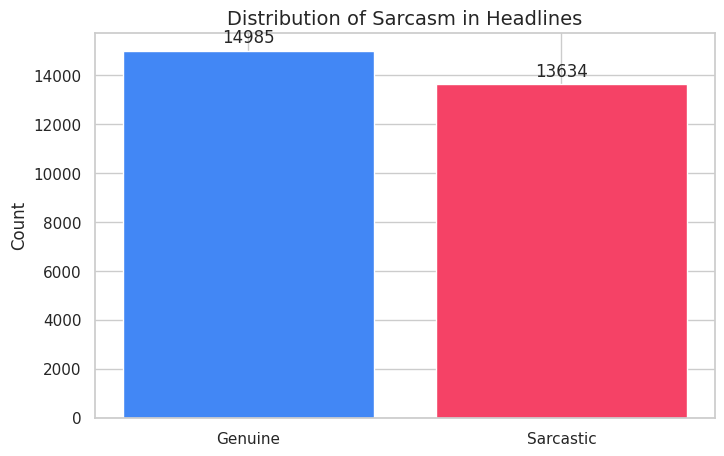

In [3]:
# Class Distribution - Equivalent to friend's code but with different colors/labels
sentiment_counts = data_frame["is_sarcastic"].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(["Genuine", "Sarcastic"], sentiment_counts.values, color=['#4287f5', '#f54266'])
plt.bar_label(bars, padding=3)
plt.title("Distribution of Sarcasm in Headlines", fontsize=14)
plt.ylabel("Count")
plt.show()

### 4. Comprehensive Preprocessing
We perform text cleaning including contraction expansion, lemmatization, and noise removal.

In [4]:
nlp_stop_words = set(stopwords.words("english"))
word_lemmatizer = WordNetLemmatizer()

def preprocess_headline(text_input):
    # Handle contractions (e.g., "don't" -> "do not")
    text_input = contractions.fix(text_input)
    text_input = text_input.lower()
    # Remove URLs, mentions, hashtags, and numbers
    text_input = re.sub(r"http\S+|@\w+|#\w+|\d+", "", text_input)
    # Remove special characters
    text_input = re.sub(r"[^a-z\s]", "", text_input)
    # Lemmatization and Stopword removal
    word_tokens = text_input.split()
    refined_tokens = [word_lemmatizer.lemmatize(w) for w in word_tokens if w not in nlp_stop_words]
    return " ".join(refined_tokens)

data_frame["refined_headline"] = data_frame["headline"].apply(preprocess_headline)
print("Sample of Preprocessed Text:")
print(data_frame[["headline", "refined_headline"]].iloc[0])

Sample of Preprocessed Text:
headline            thirtysomething scientists unveil doomsday clo...
refined_headline    thirtysomething scientist unveil doomsday cloc...
Name: 0, dtype: object


### 5. Advanced Visualization
We visualize the sarcastic vs genuine terms using dual Word Clouds.

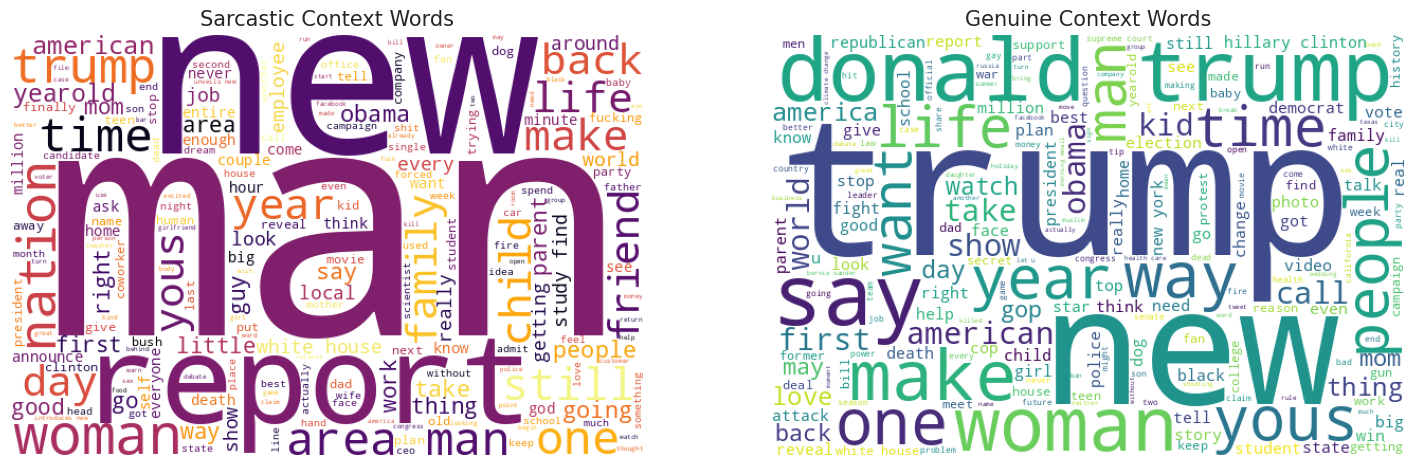

In [5]:
sarcastic_corpus = " ".join(data_frame[data_frame["is_sarcastic"] == 1]["refined_headline"])
genuine_corpus = " ".join(data_frame[data_frame["is_sarcastic"] == 0]["refined_headline"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

cloud_sarc = WordCloud(width=600, height=400, background_color="white", colormap="inferno").generate(sarcastic_corpus)
ax1.imshow(cloud_sarc)
ax1.set_title("Sarcastic Context Words", fontsize=15)
ax1.axis("off")

cloud_gen = WordCloud(width=600, height=400, background_color="white", colormap="viridis").generate(genuine_corpus)
ax2.imshow(cloud_gen)
ax2.set_title("Genuine Context Words", fontsize=15)
ax2.axis("off")

plt.show()

/tmp/ipykernel_2015/3127615246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_w), y=list(labels_w), palette="flare")


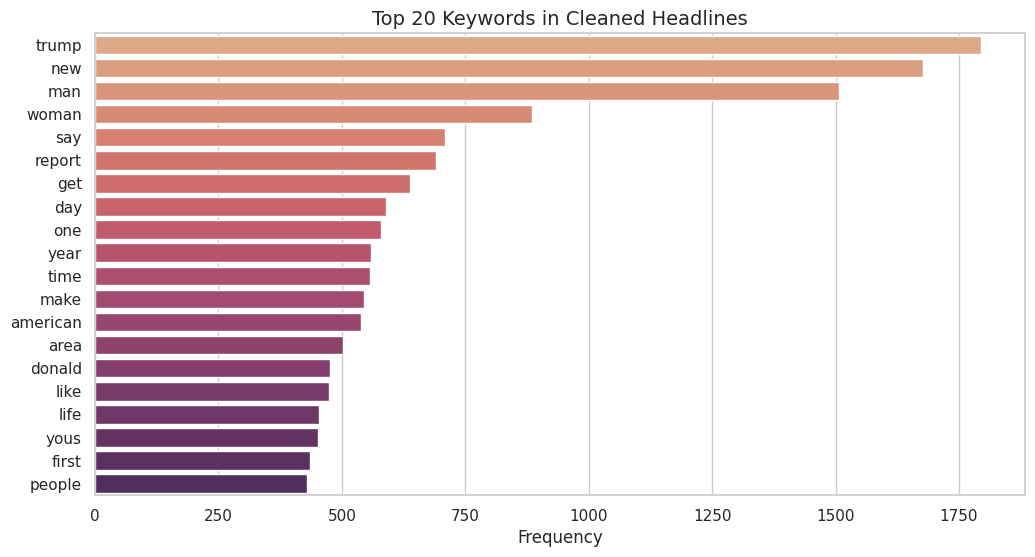

In [6]:
# Top 20 Word Frequency - Friend's code logic but re-styled
full_vocabulary = " ".join(data_frame["refined_headline"]).split()
frequency_dist = Counter(full_vocabulary).most_common(20)
labels_w, counts_w = zip(*frequency_dist)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts_w), y=list(labels_w), palette="flare")
plt.title("Top 20 Keywords in Cleaned Headlines", fontsize=14)
plt.xlabel("Frequency")
plt.show()

### 6. Tokenization, Padding, and Splitting

Sequence length at 95th percentile: 11


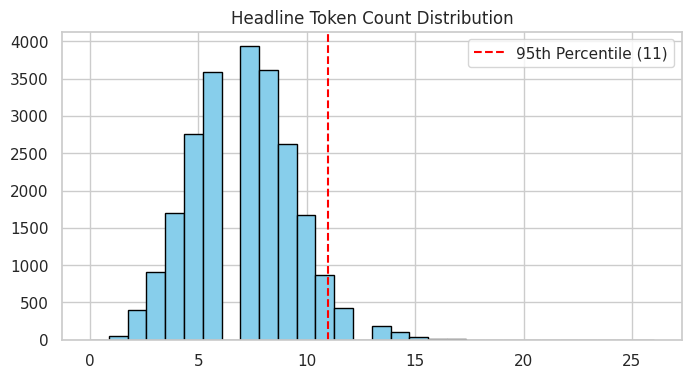

In [7]:
# Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    data_frame["refined_headline"], data_frame["is_sarcastic"], test_size=0.2, random_state=42
)

# Keras Tokenization
max_features = 12000
keras_tokenizer = Tokenizer(num_words=max_features, oov_token="<UNK>")
keras_tokenizer.fit_on_texts(X_train_raw)

train_sequences = keras_tokenizer.texts_to_sequences(X_train_raw)
test_sequences = keras_tokenizer.texts_to_sequences(X_test_raw)

# Percentile-based padding - Coursework Requirement
length_of_sequences = [len(x) for x in train_sequences]
optimal_len = int(np.percentile(length_of_sequences, 95))
print(f"Sequence length at 95th percentile: {optimal_len}")

X_train = pad_sequences(train_sequences, maxlen=optimal_len, padding='pre')
X_test = pad_sequences(test_sequences, maxlen=optimal_len, padding='pre')

plt.figure(figsize=(8, 4))
plt.hist(length_of_sequences, bins=30, color='skyblue', edgecolor='black')
plt.axvline(optimal_len, color='red', linestyle='--', label=f'95th Percentile ({optimal_len})')
plt.title("Headline Token Count Distribution")
plt.legend()
plt.show()

### 7. Model Implementations (Keras)
We build three models to compare architectural performance.

In [8]:
def compile_and_train(model, X_tr, y_tr, X_val, y_val, model_name):
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    stop_callback = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    print(f"\nTraining {model_name}...")
    start_time = time.time()
    history = model.fit(
        X_tr, y_tr,
        epochs=10,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[stop_callback],
        verbose=1
    )
    duration = time.time() - start_time
    return history, duration

# Model 1: Simple RNN
rnn_engine = Sequential([
    Embedding(max_features, 100, input_length=optimal_len),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

hist_rnn, time_rnn = compile_and_train(rnn_engine, X_train, y_train, X_test, y_test, "Simple RNN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training Simple RNN...
Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.7392 - loss: 0.5094 - val_accuracy: 0.8073 - val_loss: 0.4186
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8996 - loss: 0.2498 - val_accuracy: 0.7898 - val_loss: 0.4879
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9674 - loss: 0.0920 - val_accuracy: 0.7851 - val_loss: 0.6244
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9884 - loss: 0.0347 - val_accuracy: 0.7800 - val_loss: 0.8705


In [9]:
# Model 2: LSTM
lstm_engine = Sequential([
    Embedding(max_features, 100, input_length=optimal_len),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

hist_lstm, time_lstm = compile_and_train(lstm_engine, X_train, y_train, X_test, y_test, "LSTM")


Training LSTM...
Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7408 - loss: 0.5049 - val_accuracy: 0.8024 - val_loss: 0.4192
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8715 - loss: 0.3079 - val_accuracy: 0.8125 - val_loss: 0.4186
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9192 - loss: 0.2013 - val_accuracy: 0.8094 - val_loss: 0.4864
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9520 - loss: 0.1271 - val_accuracy: 0.8022 - val_loss: 0.5516
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9707 - loss: 0.0804 - val_accuracy: 0.7872 - val_loss: 0.7960


In [10]:
# Model 3: LSTM with Pre-trained Word2Vec Embeddings
print("Fetching Pre-trained Word2Vec (Google News)...")
w2v_vectors = api.load("word2vec-google-news-300")

embedding_matrix = np.zeros((max_features, 300))
for word, index in keras_tokenizer.word_index.items():
    if index < max_features:
        if word in w2v_vectors:
            embedding_matrix[index] = w2v_vectors[word]

w2v_embedding_layer = Embedding(
    input_dim=max_features,
    output_dim=300,
    weights=[embedding_matrix],
    input_length=optimal_len,
    trainable=False
)

w2v_lstm_engine = Sequential([
    w2v_embedding_layer,
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

hist_w2v, time_w2v = compile_and_train(w2v_lstm_engine, X_train, y_train, X_test, y_test, "LSTM + Word2Vec")

Fetching Pre-trained Word2Vec (Google News)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Training LSTM + Word2Vec...
Epoch 1/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7247 - loss: 0.5396 - val_accuracy: 0.7628 - val_loss: 0.4912
Epoch 2/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7738 - loss: 0.4722 - val_accuracy: 0.7729 - val_loss: 0.4729
Epoch 3/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7986 - loss: 0.4368 - val_accuracy: 0.7858 - val_loss: 0.4422
Epoch 4/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8133 - loss: 0.4019 - val_accuracy: 0.7841 - val_loss: 0.4470
Epoch 5/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8318 - loss: 0.3735 - val_accuracy: 0.8043 - val_loss: 0.4218
Epoch 6/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8466 - loss: 0.3438 - val_accuracy: 0.8024 - val_loss: 0.4185
Epoch 7/10
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy

### 8. Performance Comparison
We visualize the learning curves and final metrics for all models.

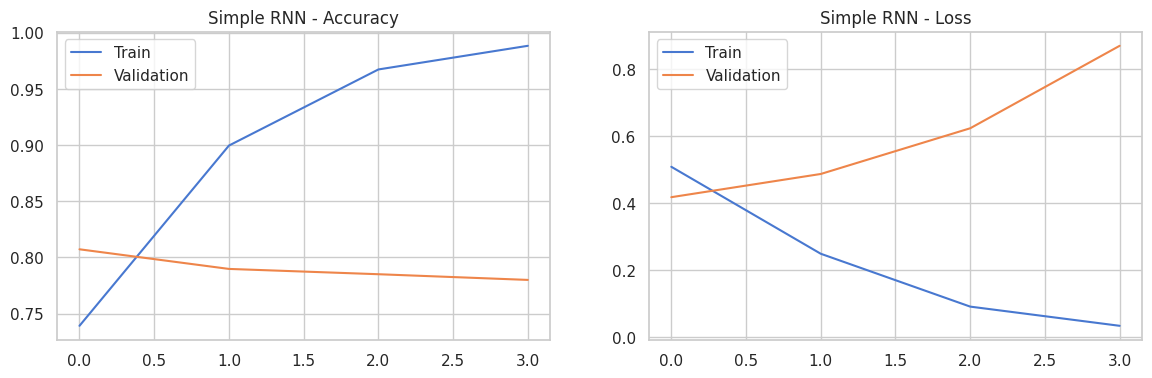

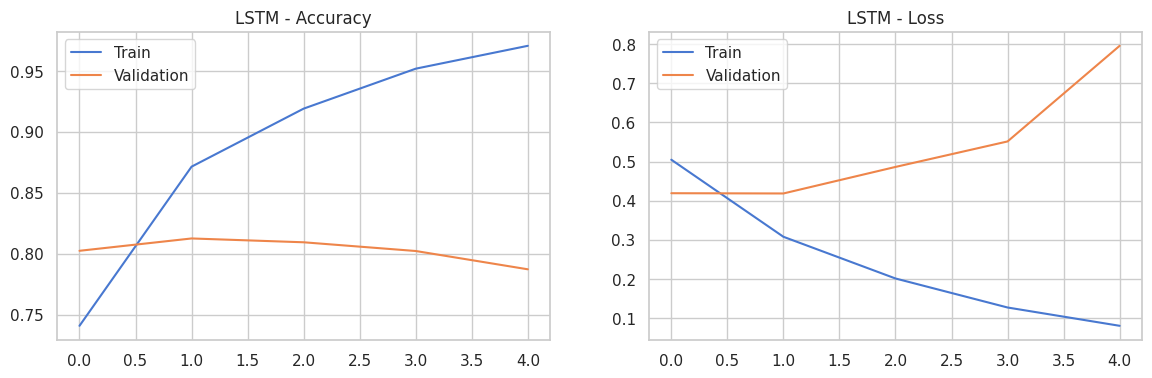

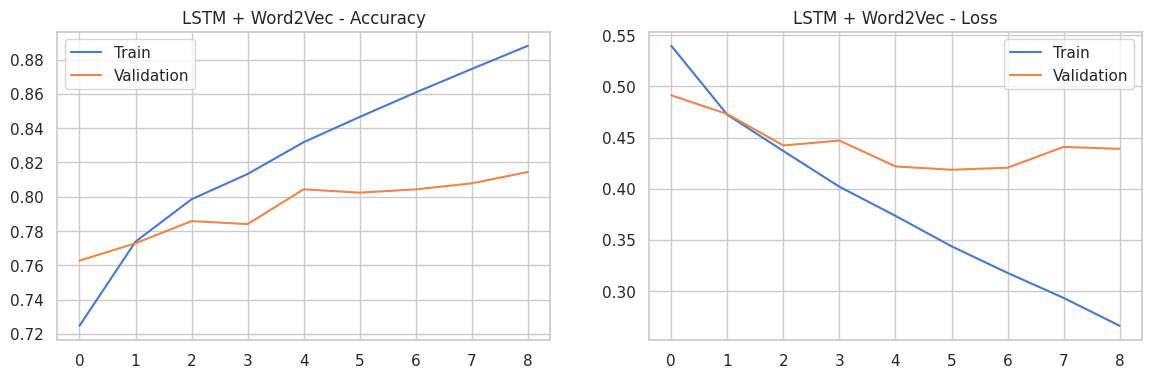

In [11]:
def visualize_results(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Loss')
    ax2.legend()
    plt.show()

visualize_results(hist_rnn, "Simple RNN")
visualize_results(hist_lstm, "LSTM")
visualize_results(hist_w2v, "LSTM + Word2Vec")

### 9. Evaluation Metrics & Error Analysis

179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


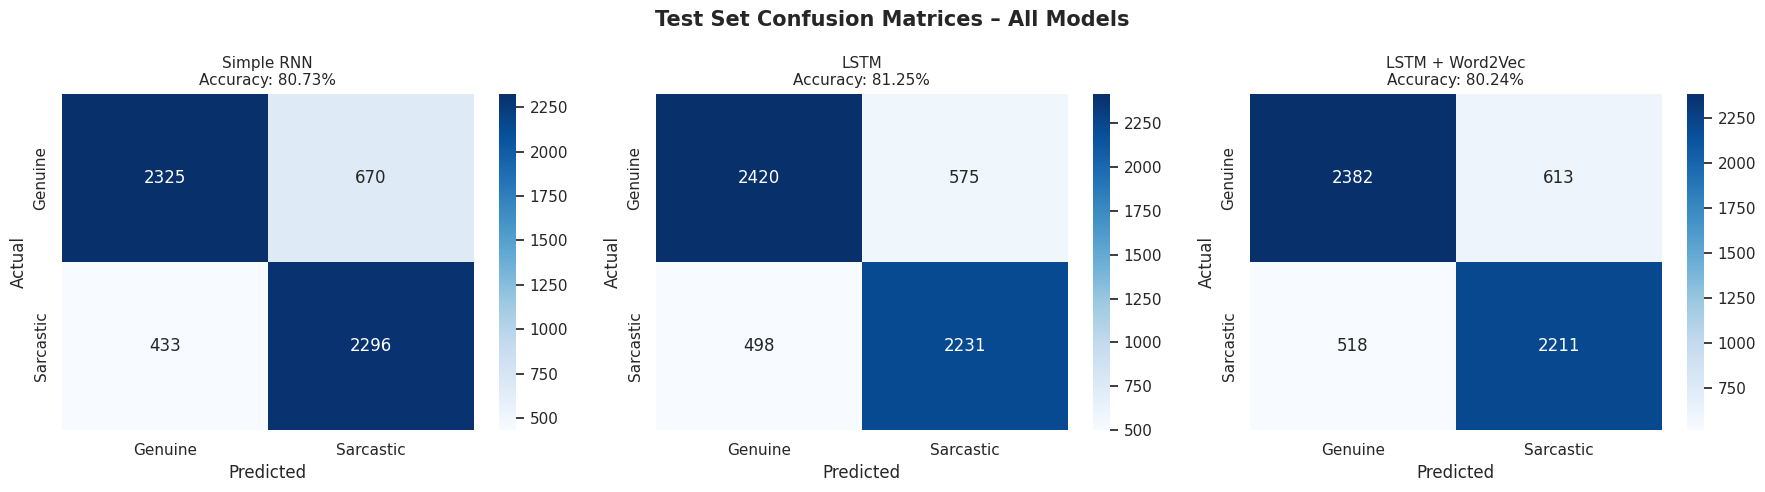

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Simple RNN Classification Report ---
              precision    recall  f1-score   support

     Genuine       0.84      0.78      0.81      2995
   Sarcastic       0.77      0.84      0.81      2729

    accuracy                           0.81      5724
   macro avg       0.81      0.81      0.81      5724
weighted avg       0.81      0.81      0.81      5724

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- LSTM Classification Report ---
              precision    recall  f1-score   support

     Genuine       0.83      0.81      0.82      2995
   Sarcastic       0.80      0.82      0.81      2729

    accuracy                           0.81      5724
   macro avg       0.81      0.81      0.81      5724
weighted avg       0.81      0.81      0.81      5724

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- LSTM + Word2Vec Classification Report ---
              precision    recall  f1-score   support

     Genuine       0.82      0.80      0.81

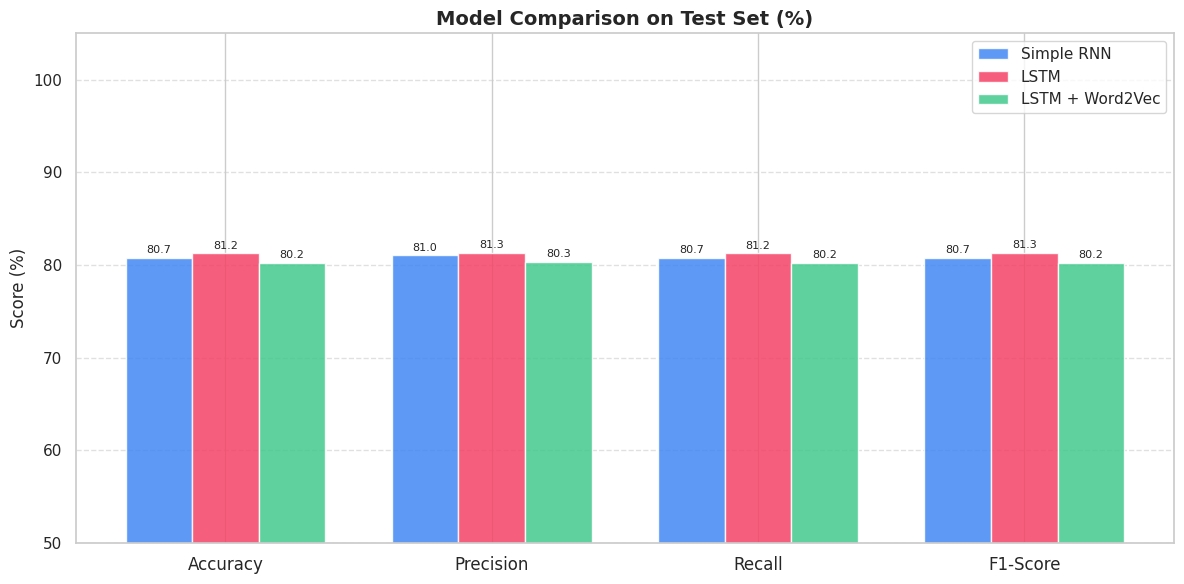


=== Model Performance Summary ===
                 Accuracy  Precision  Recall  F1-Score
Simple RNN          80.73      81.02   80.73     80.73
LSTM                81.25      81.30   81.25     81.26
LSTM + Word2Vec     80.24      80.30   80.24     80.25
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- Analysis of Misclassified Examples (LSTM) ---
Headline: state slow shut weak teacher education program
Actual: 0 | Predicted: 1
------------------------------
Headline: massive filament snake across sun surface
Actual: 0 | Predicted: 1
------------------------------
Headline: track winning reinvested blackjack future
Actual: 1 | Predicted: 0
------------------------------


In [12]:
# Evaluate all 3 models and collect results for comparison

models_info = [
    (rnn_engine,       "Simple RNN"),
    (lstm_engine,      "LSTM"),
    (w2v_lstm_engine,  "LSTM + Word2Vec"),
]

results = {}

# --- Confusion Matrices (side-by-side) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Test Set Confusion Matrices – All Models", fontsize=15, fontweight='bold')

for ax, (model, name) in zip(axes, models_info):
    preds = (model.predict(X_test) > 0.5).astype("int32").flatten()
    acc   = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True)
    results[name] = {
        'Accuracy':  round(acc * 100, 2),
        'Precision': round(report['weighted avg']['precision'] * 100, 2),
        'Recall':    round(report['weighted avg']['recall'] * 100, 2),
        'F1-Score':  round(report['weighted avg']['f1-score'] * 100, 2),
    }
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Genuine', 'Sarcastic'],
                yticklabels=['Genuine', 'Sarcastic'],
                ax=ax)
    ax.set_title(f"{name}\nAccuracy: {acc*100:.2f}%", fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- Classification Reports ---
for model, name in models_info:
    preds = (model.predict(X_test) > 0.5).astype("int32").flatten()
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, preds, target_names=['Genuine', 'Sarcastic']))

# --- 3-Model Comparison Bar Plot ---
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(results.keys())
x           = np.arange(len(metrics))
width       = 0.25
colors      = ['#4287f5', '#f54266', '#42c98d']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)

ax.set_title('Model Comparison on Test Set (%)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score (%)')
ax.set_ylim(50, 105)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n=== Model Performance Summary ===")
summary_df = pd.DataFrame(results).T
print(summary_df.to_string())

# --- Error Analysis on Best Model (LSTM) ---
preds_final = (lstm_engine.predict(X_test) > 0.5).astype("int32").flatten()
print("\n--- Analysis of Misclassified Examples (LSTM) ---")
mismatch_indices = np.where(preds_final != y_test.values)[0]
for i in mismatch_indices[:3]:
    print(f"Headline: {X_test_raw.iloc[i]}")
    print(f"Actual: {y_test.iloc[i]} | Predicted: {preds_final[i]}")
    print("-" * 30)



### 10. Model Export for Deployment

In [14]:
w2v_lstm_engine.save('final/sarcasm_predictor.h5')
with open('final/tokenizer_v2.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)
print("Project components saved for Streamlit deployment.")

Project components saved for Streamlit deployment.
